In [2]:
!pip install librosa


  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached numba-0.64.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached numpy-2.4.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp312-abi3-win_amd64.whl.metadata (5.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached msgpack-1.1.2-cp313-cp313-win_amd64.whl.metadata (8.4 kB)
  Using cached standard_aifc-3.13.0-py3-none-any.whl.metadata (969 bytes)
  Using cached standa


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import numpy as np
import librosa
from tqdm import tqdm

In [2]:
dataset_path = r"E:\4-2 project\Italian Parkinson's Voice and speech"

In [3]:
def extract_mfcc(file_path, max_pad_len=174):
    
    audio, sr = librosa.load(file_path, sr=22050)
    
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    
    pad_width = max_pad_len - mfcc.shape[1]
    
    if pad_width > 0:
        mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
    else:
        mfcc = mfcc[:,:max_pad_len]
    
    return mfcc

In [4]:
X = []
y = []

healthy_folders = [
"15 Young Healthy Control",
"22 Elderly Healthy Control"
]

# Healthy
for folder in healthy_folders:
    
    
    folder_path = os.path.join(dataset_path, folder)
    
    for person in os.listdir(folder_path):
        
        person_path = os.path.join(folder_path, person)
        
        if not os.path.isdir(person_path):
            continue
        
        for file in os.listdir(person_path):
            
            if file.endswith(".wav"):
                
                file_path = os.path.join(person_path,file)
                
                mfcc = extract_mfcc(file_path)
                
                X.append(mfcc)
                y.append(0)

# Parkinsons
pd_path = os.path.join(dataset_path,"28 People with Parkinson's disease")

for group in os.listdir(pd_path):

    group_path = os.path.join(pd_path, group)

    # Skip files like .xlsx
    if not os.path.isdir(group_path):
        continue

    for person in os.listdir(group_path):

        person_path = os.path.join(group_path, person)

        # Skip if not directory
        if not os.path.isdir(person_path):
            continue

        for file in os.listdir(person_path):

            if file.endswith(".wav"):

                file_path = os.path.join(person_path, file)

                mfcc = extract_mfcc(file_path)

                X.append(mfcc)
                y.append(1)
X = np.array(X)
y = np.array(y)

print(X.shape,y.shape)

(831, 40, 174) (831,)


In [5]:
X = X[..., np.newaxis]

print(X.shape)

(831, 40, 174, 1)


In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Bidirectional,LSTM
from tensorflow.keras.layers import Dense,Dropout,Flatten

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Reshape, Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Input(shape=(40,174,1)))

# CNN
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

# Correct reshape
model.add(Reshape((-1,64)))

# BiLSTM
model.add(Bidirectional(LSTM(64)))

model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 336, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,993 (332.00 KB)

 Trainable params: 84,993 (332.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
X_train,y_train,
epochs=30,
batch_size=32,
validation_data=(X_test,y_test)
)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 614ms/step - accuracy: 0.6220 - loss: 0.6387 - val_accuracy: 0.7365 - val_loss: 0.5545
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 563ms/step - accuracy: 0.7259 - loss: 0.5479 - val_accuracy: 0.7605 - val_loss: 0.5143
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 507ms/step - accuracy: 0.7877 - loss: 0.4832 - val_accuracy: 0.8084 - val_loss: 0.4439
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 498ms/step - accuracy: 0.8373 - loss: 0.4078 - val_accuracy: 0.8623 - val_loss: 0.3690
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 392ms/step - accuracy: 0.8705 - loss: 0.3485 - val_accuracy: 0.8683 - val_loss: 0.3268
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 541ms/step - accuracy: 0.8705 - loss: 0.3174 - val_accuracy: 0.9102 - val_loss: 0.2756
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 570ms/step - accuracy: 0.8991 - loss: 0.2641 - val_accuracy: 0.9222 - val_loss: 0.2437
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 448ms/step - accuracy: 0.9142 - loss: 0.2343 - val_accu

In [10]:
loss,acc = model.evaluate(X_test,y_test)

print("Accuracy:",acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.9641 - loss: 0.1036
Accuracy: 0.9640718698501587


In [11]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 292ms/step


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9640718562874252


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96        72
           1       0.96      0.98      0.97        95

    accuracy                           0.96       167
   macro avg       0.97      0.96      0.96       167
weighted avg       0.96      0.96      0.96       167



In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[68  4]
 [ 2 93]]


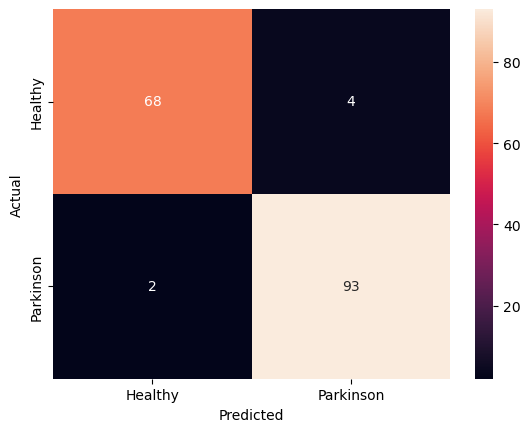

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Healthy','Parkinson'],
            yticklabels=['Healthy','Parkinson'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

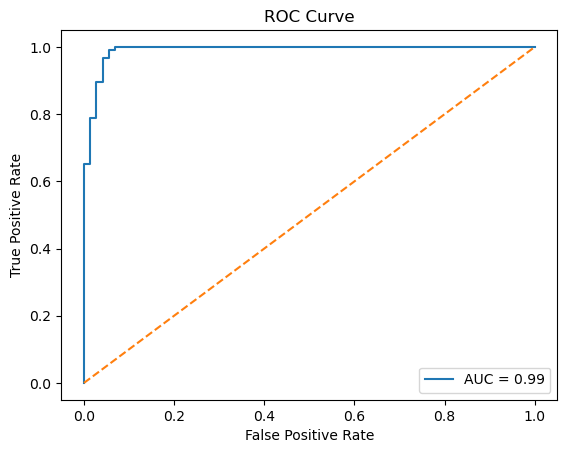

In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [17]:
print("AUC Score:", roc_auc)

AUC Score: 0.9902046783625731


In [18]:
from sklearn.model_selection import KFold
import numpy as np

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D
from tensorflow.keras.layers import Reshape,Bidirectional,LSTM
from tensorflow.keras.layers import Dense,Dropout

def create_model():

    model = Sequential()

    model.add(Input(shape=(40,174,1)))

    model.add(Conv2D(32,(3,3),activation='relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64,(3,3),activation='relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Reshape((-1,64)))

    model.add(Bidirectional(LSTM(64)))

    model.add(Dropout(0.5))

    model.add(Dense(1,activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [20]:
kfold = KFold(n_splits=5,shuffle=True,random_state=42)

accuracies = []

for train_index,test_index in kfold.split(X):

    X_train,X_test = X[train_index],X[test_index]
    y_train,y_test = y[train_index],y[test_index]

    model = create_model()

    model.fit(
        X_train,y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    loss,acc = model.evaluate(X_test,y_test,verbose=0)

    accuracies.append(acc)

    print("Fold Accuracy:",acc)

Fold Accuracy: 0.9640718698501587
Fold Accuracy: 0.9698795080184937
Fold Accuracy: 0.9457831382751465
Fold Accuracy: 0.9397590160369873
Fold Accuracy: 0.9578313231468201


In [21]:
print("Average Accuracy:",np.mean(accuracies))
print("Standard Deviation:",np.std(accuracies))

Average Accuracy: 0.9554649710655212
Standard Deviation: 0.011205999410756493


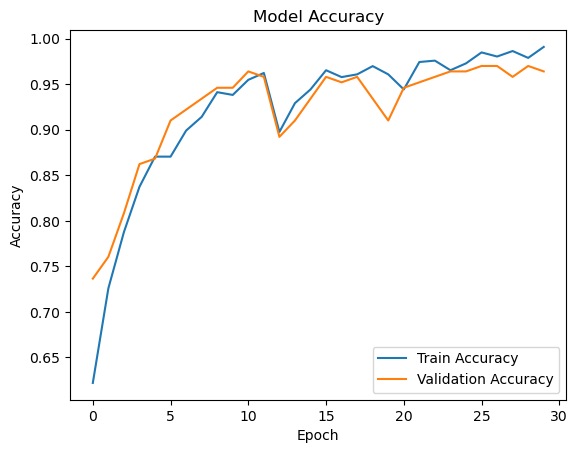

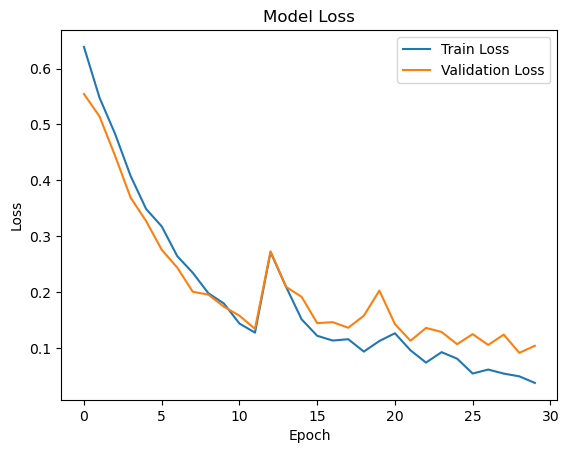

In [22]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [34]:
# ===============================
# SENSITIVITY & SPECIFICITY
# ===============================
TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("\n===== EXTRA METRICS =====")
print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")


===== EXTRA METRICS =====
Sensitivity : 0.9789
Specificity : 0.9444


In [37]:
# ===============================
# SINGLE FILE PREDICTION (FIXED)
# ===============================
def predict_single_file(file_path):
    mfcc = extract_mfcc(file_path)
    if mfcc is None:
        print("Error in feature extraction")
        return
    mfcc = np.expand_dims(mfcc, axis=0)
    prob = model.predict(mfcc)[0][0]
    print("\n===== SINGLE FILE RESULT =====")
    print(f"Healthy Probability   : {1 - prob:.4f}")
    print(f"Parkinson Probability : {prob:.4f}")
    if prob >= 0.5:
        print("Prediction: Parkinson's Disease")
    else:
        print("Prediction: Healthy")
predict_single_file(r"E:\4-2 project\Italian Parkinson's Voice and speech\15 Young Healthy Control\Giuseppe M\B1LBULCAAS94M100120171043.wav")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

===== SINGLE FILE RESULT =====
Healthy Probability   : 0.8653
Parkinson Probability : 0.1347
Prediction: Healthy
